In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import jax
import os
import json
import cloudpickle
import sys
sys.path.append(os.path.abspath(".."))
import os
os.environ["JAX_PLATFORMS"] = "cpu"
from IPython.display import FileLink, display, HTML
from mail import *
import jax
import jax.numpy as jnp
print(jax.devices())  # Should list CPU devices only
from plot_utils import plot_experiments, load_run_data, make_table
import matplotlib.pyplot as plt
import numpy as np
from core.configs import FINAL_TESTING
from notebooks.mail import email_pdf

def plot_final_testing(RUNS, registry=FINAL_TESTING):
    plt.style.use('seaborn-v0_8-paper')
    
    # 1. Flatten all groups into a list of (group_key, env_name) pairs
    all_tasks = []
    for group_key, details in registry.items():
        for env_name in details['envs']:
            all_tasks.append((group_key, env_name))
            
    # 2. Calculate Grid
    n_plots = len(all_tasks)
    n_cols = 4
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3), constrained_layout=True)
    axes = axes.flatten()
        
    handles, labels = [], []

    for i, (group_key, base_env_name) in enumerate(all_tasks):
        ax = axes[i]
        details = registry[group_key]
        size = details['config_dict'].get('ENV_SIZE', None)

        # 3. Handle the Environment ID formatting
        if size is not None:
            formatted_env_id = f"{base_env_name}-{size}"
        else:
            formatted_env_id = base_env_name
            
        ax.set_title(f"{formatted_env_id}\n({group_key})", fontweight='bold', fontsize=9)

        # 4. Metric Selection
        return_metric = 'returned_episode_returns'
        # Environments that typically use discounted returns for evaluation
        if any(x in group_key for x in ['chain', 'four_rooms', 'visual']) or "Discounting" in base_env_name:
            return_metric = 'returned_discounted_episode_returns'

        for run in RUNS:
            try:
                config, metrics = load_run_data(run["run_dir"], formatted_env_id)
                
                # Check if data exists for this specific env in this run
                if return_metric in metrics:
                    rets = metrics[return_metric].mean(0)
                    line, = ax.plot(rets, label=run["name"], color=run["color"], alpha=0.8, linewidth=1.5)

                    if run["name"] not in labels:
                        handles.append(line)
                        labels.append(run["name"])
            except Exception:
                continue

    # Cleanup unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=10)
    return fig

In [32]:
# Define the algorithms and the specific batch date
algs = ["ppo", "grpo", "net", "lstd2", "lspi", "distill", "learned_feats"]
batch_date = "4_17"

# Generate the new RUNS list
ALL_RUNS = []
colors = plt.cm.tab10(np.linspace(0, 1, len(algs))) # Automatic distinct colors

for i, alg in enumerate(algs):
    ALL_RUNS.append({
        "run_dir": f"4_16_{alg}/{batch_date}",
        "name": alg.replace("_", " ").upper(), # e.g., "LEARNED FEATS"
        "color": colors[i],
        "alpha": 0.8
    })

ppo_vs_expl = ALL_RUNS[0:3]
lstd_methods = ALL_RUNS[3:]
learned_vi = ALL_RUNS[2:]


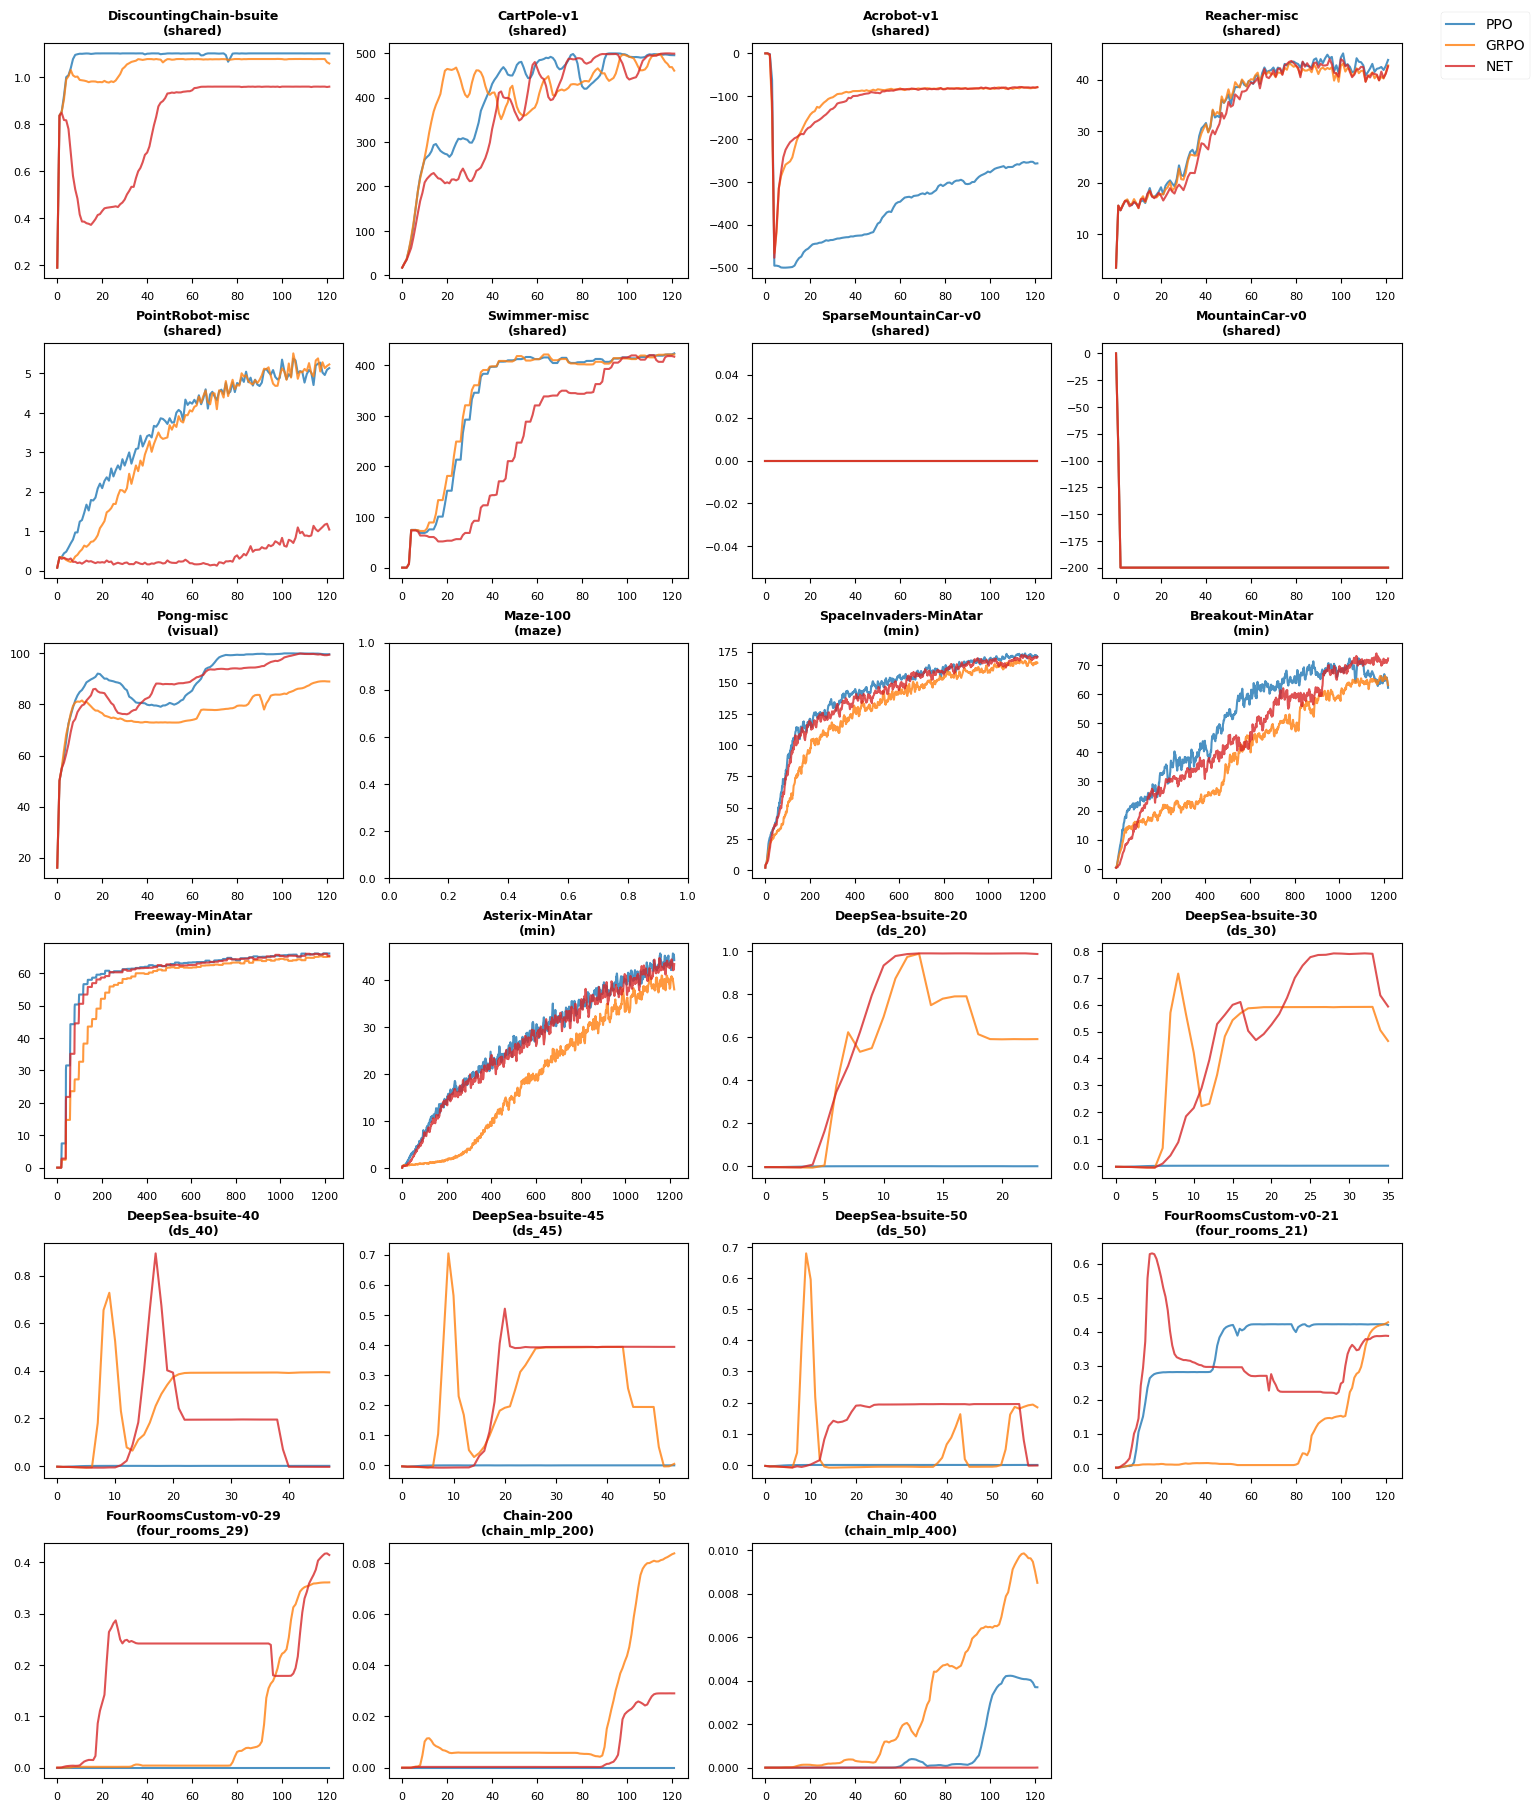

In [33]:
fig1 = plot_final_testing(ppo_vs_expl)


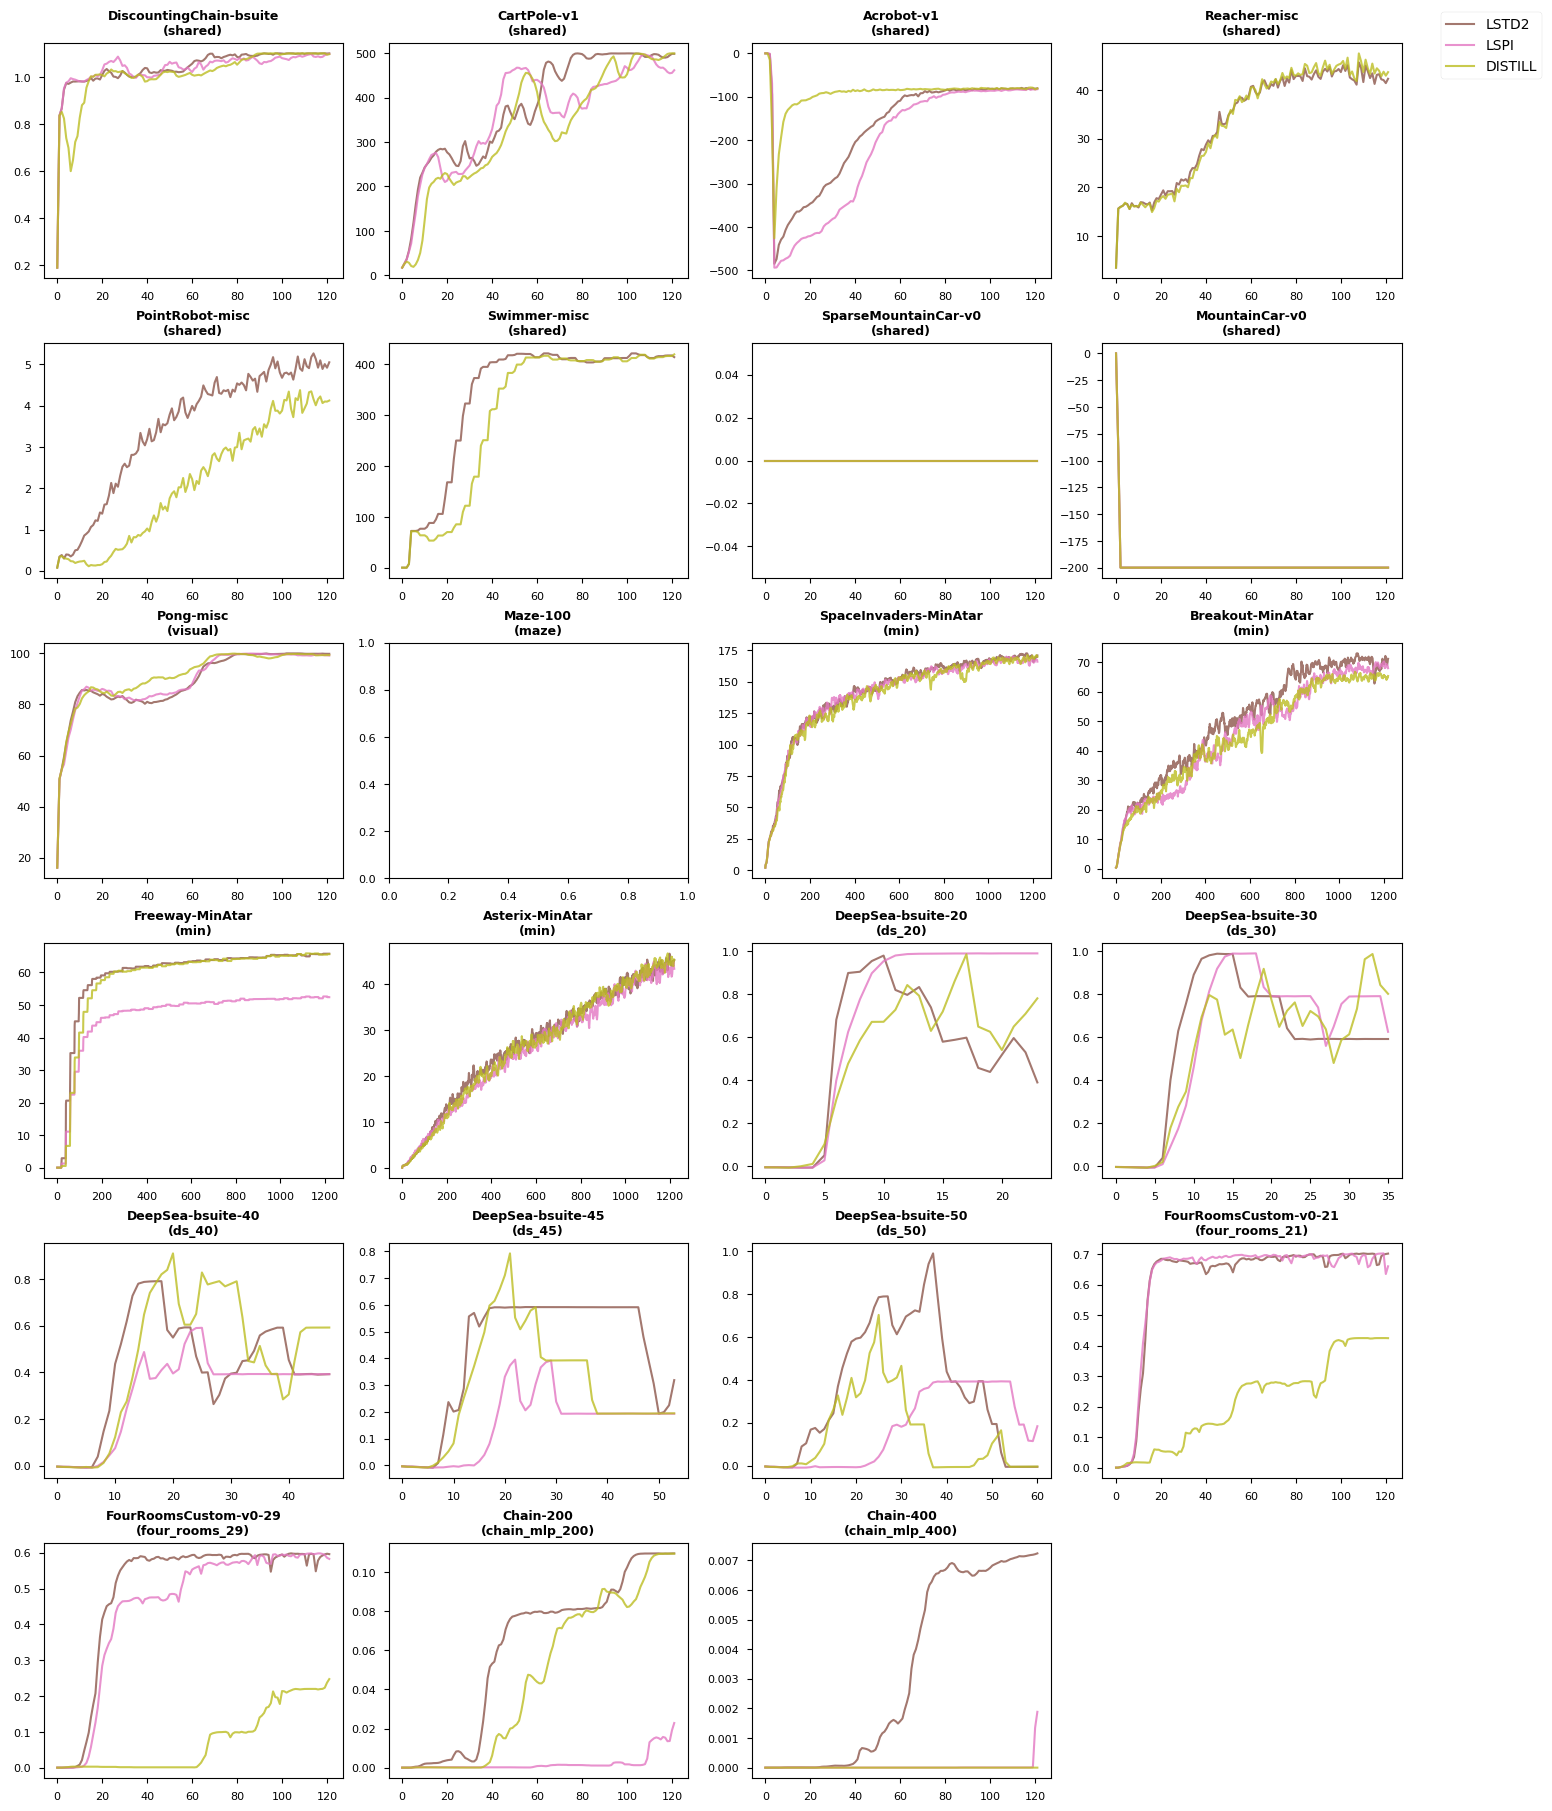

In [34]:
fig = plot_final_testing(lstd_methods)
